# VAE com Perceptual Loss: Geração de Imagens de Normal

- **Loss = MSE (pixel) + Perceptual Loss (VGG features) + KLD**
- A VGG compara features intermédias (não pixel a pixel) usada para  preservar ductos e texturas
- Treina um VAE novo desde o início com esta loss
- Imagens guardadas em `./vae_generated_perceptual/Normal/`

## Imports

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.utils import make_grid, save_image

# A VGG16 é importada para ser usada como extractor de features na Perceptual Loss
# (não é treinada é apenas usada em modo de inferência).
from torchvision.models import vgg16, VGG16_Weights
from torchinfo import summary
from livelossplot import PlotLosses

from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, Resize,
    NormalizeIntensity, Lambda, ToTensor
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Configuração

In [3]:
DATASET_BASE = './dataset_monica' # path para a pasta com train/val/test
OUTPUT_DIR    = './vae_generated_perceptual'   # pasta diferente da primeira abordagem
MODEL_PATH    = './vae_perceptual_normal.pth' # path para guardar/carregar o modelo VAE
TARGET_CLASS  = 'Normal'# Target class: só imagens desta classe são usadas

# resolução de treino do VAE (128x128)
# escolhida para evitar overfitting porque temos bue poucas imagens
# o classificador faz resize via MONAI transforms
IMG_SIZE      = 128

LATENT_DIM    = 256 # dimensão do espaço latente
BATCH_SIZE    = 16  # batch pequeno adequado ao dataset reduzido
EPOCHS        = 150 # número máximo de epochs de treino
LEARNING_RATE = 1e-3 # lr inicial


# Pesos da loss composta: Loss = MSE_W*MSE + PERC_W*Perceptual + KLD_W*KLD
# MSE_W=1.0 - peso dominante: garante reconstrução fiel ao nível do pixel
# PERC_W=0.001 - peso pequeno mas suficiente para preservar ductos e texturas
# KLD_W=0.0001 - muito pequeno para não suprimir a qualidade de reconstrução
MSE_W   = 1.0    
PERC_W  =0.001      
KLD_W   = 0.0001  

# Escala do ruído adicionado ao mu na geração:
# valor pequeno garante que as imagens geradas ficam perto das reais
NOISE_SCALE  = 0.05   
N_GENERATE   = 300 # número de imagens sintéticas a gerar

os.makedirs(f'{OUTPUT_DIR}/{TARGET_CLASS}', exist_ok=True)
print(f'Config OK — MSE_W={MSE_W}, PERC_W={PERC_W}, KLD_W={KLD_W}')

Config OK — MSE_W=1.0, PERC_W=0.001, KLD_W=0.0001


## Dataset

In [4]:
# Carregamento de Normal
# O VAE é treinado apenas com imagens desta classe
# Isto garante que o espaço latente aprende exclusivamente a distribuição
# desta classe, permitindo gerar variações realistas da mesma patologia

class SingleClassDataset(Dataset):
    def __init__(self, root, class_name, img_size=128):
        class_dir = Path(root) / 'train' / class_name
        self.img_paths = sorted([
            str(p) for p in class_dir.rglob('*')
            if p.suffix.lower() in {'.png', '.jpg', '.jpeg'}
        ])
        print(f'Imagens encontradas para {class_name}: {len(self.img_paths)}')
        self.transforms = Compose([
            LoadImage(image_only=True),
            EnsureChannelFirst(),
            Resize((img_size, img_size)),
            NormalizeIntensity(),
            Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
            ToTensor()
        ])

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = self.transforms(self.img_paths[idx])
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        return img.float()


dataset  = SingleClassDataset(DATASET_BASE, TARGET_CLASS, IMG_SIZE)
train_dl = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
print(f'Batches por epoch: {len(train_dl)}')

Imagens encontradas para Normal: 197
Batches por epoch: 13


## Visualizar imagens reais

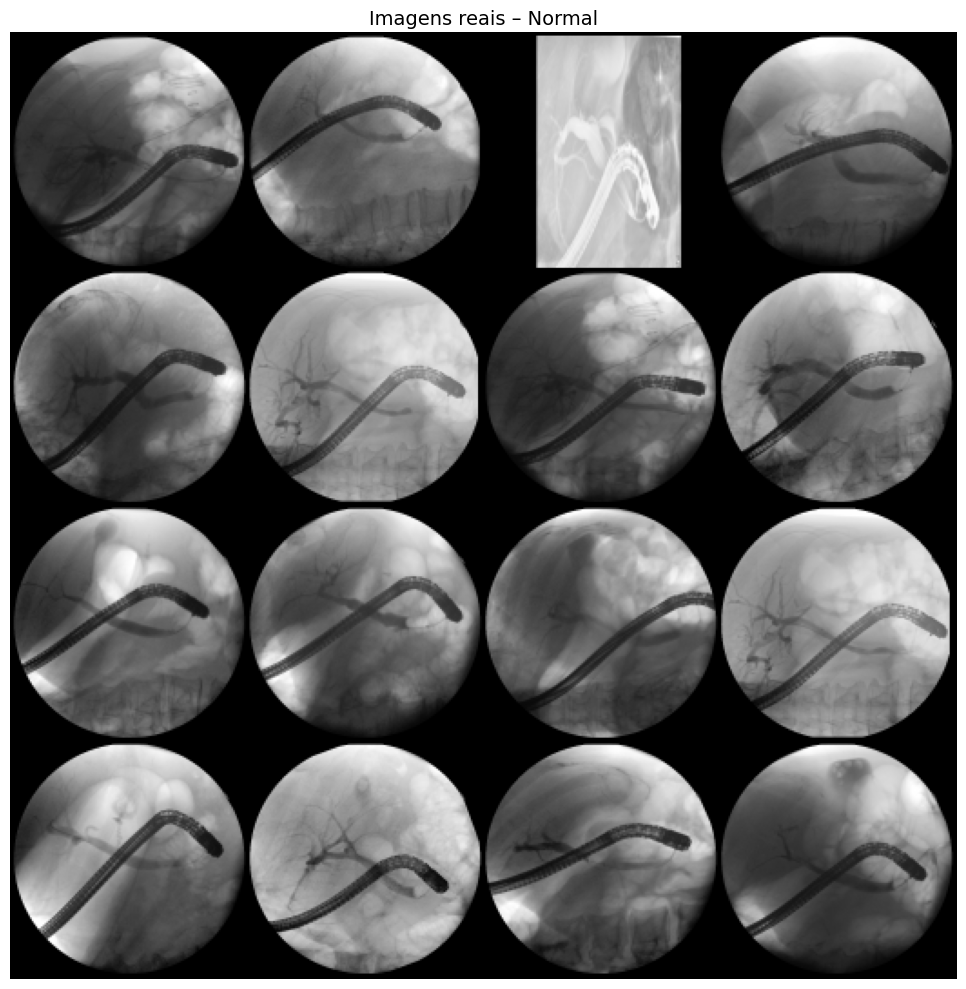

In [5]:
def show_images(imgs, title='', n=16):
    imgs = imgs[:n]
    grid = make_grid(imgs, nrow=4, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.tight_layout()
    plt.show()

batch = next(iter(train_dl))
show_images(batch, title=f'Imagens reais – {TARGET_CLASS}')

## Arquitectura do VAE


In [6]:
# ARQUITETURA: Variational Autoencoder Convolucional (ConvVAE)
#
# Estrutura:
#   Encoder: 4 blocos Conv2d (stride=2)- reduz 128x128 para 8x8, 3 canais para 256
#   Cabeças variacionais: fc_mu e fc_log_var - produzem média e variância do espaço latente
#   Reparameterization trick: z = mu + exp(0.5*log_var) * epsilon 
#   Decoder: 4 blocos ConvTranspose2d - reconstrói 8x8 para 128x128
#
# O método forward() retorna (recon, mu, log_var, z) 
class ConvVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=256, img_size=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.img_size   = img_size

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.feat_size = img_size // 16
        self.flat_dim  = 256 * self.feat_size * self.feat_size

        self.fc_mu      = nn.Linear(self.flat_dim, latent_dim)
        self.fc_log_var = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode  = nn.Linear(latent_dim, self.flat_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, in_channels, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        if self.training:
            return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        return mu

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 256, self.feat_size, self.feat_size)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var, z


model = ConvVAE(in_channels=3, latent_dim=LATENT_DIM, img_size=IMG_SIZE).to(device)
print(summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE), verbose=0))

Layer (type:depth-idx)                   Output Shape              Param #
ConvVAE                                  [16, 3, 128, 128]         --
├─Sequential: 1-1                        [16, 256, 8, 8]           --
│    └─Conv2d: 2-1                       [16, 32, 64, 64]          1,568
│    └─BatchNorm2d: 2-2                  [16, 32, 64, 64]          64
│    └─LeakyReLU: 2-3                    [16, 32, 64, 64]          --
│    └─Conv2d: 2-4                       [16, 64, 32, 32]          32,832
│    └─BatchNorm2d: 2-5                  [16, 64, 32, 32]          128
│    └─LeakyReLU: 2-6                    [16, 64, 32, 32]          --
│    └─Conv2d: 2-7                       [16, 128, 16, 16]         131,200
│    └─BatchNorm2d: 2-8                  [16, 128, 16, 16]         256
│    └─LeakyReLU: 2-9                    [16, 128, 16, 16]         --
│    └─Conv2d: 2-10                      [16, 256, 8, 8]           524,544
│    └─BatchNorm2d: 2-11                 [16, 256, 8, 8]          

## Perceptual Loss com VGG16

Extrai features das camadas intermédias da VGG16 pré-treinada e compara original vs reconstrução.

```
Loss total = MSE(pixel) + PERC_W * MSE(vgg_features) + KLD_W * KLD
```

A VGG fica **frozen** (não treina) só serve apenas como extractor de features.

In [7]:
class PerceptualLoss(nn.Module):
    """
    Compara features intermédias da VGG16 entre imagem original e reconstruída.
    Usa as camadas relu1_2, relu2_2, relu3_3 — capturam texturas e estruturas.
    """
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features
        # Extrair blocos de features: até relu1_2, relu2_2, relu3_3
        self.slice1 = nn.Sequential(*list(vgg)[:4]).eval()   # relu1_2
        self.slice2 = nn.Sequential(*list(vgg)[4:9]).eval()  # relu2_2
        self.slice3 = nn.Sequential(*list(vgg)[9:16]).eval() # relu3_3
        # Congelar pq a VGG não treina
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, recon, target):
        # Passar pelas 3 camadas e comparar features
        loss = 0.0
        r, t = recon, target
        for slc in [self.slice1, self.slice2, self.slice3]:
            r = slc(r)
            t = slc(t)
            loss += F.mse_loss(r, t)
        return loss


perceptual_loss_fn = PerceptualLoss().to(device)
print('PerceptualLoss (VGG16) carregada e frozen.')


def vae_perceptual_loss(recon, x, mu, log_var, perc_fn, mse_w, perc_w, kld_w):
    mse  = F.mse_loss(recon, x, reduction='mean')
    perc = perc_fn(recon, x)
    kld = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return mse_w * mse + perc_w * perc + kld_w * kld

PerceptualLoss (VGG16) carregada e frozen.


## Treino
Características principais:
- Optimizer Adam com learning rate 1e-3
- ReduceLROnPlateau: reduz LR a metade se loss não melhorar em 15 epochs
(critério de adaptação da taxa de aprendizagem: não para o treino)
- Gradient clipping (max_norm=1.0): limita o tamanho dos gradientes para
evitar explosões numéricas causadas pela Perceptual Loss
- Guarda o modelo com menor loss de treino ao longo das epochs

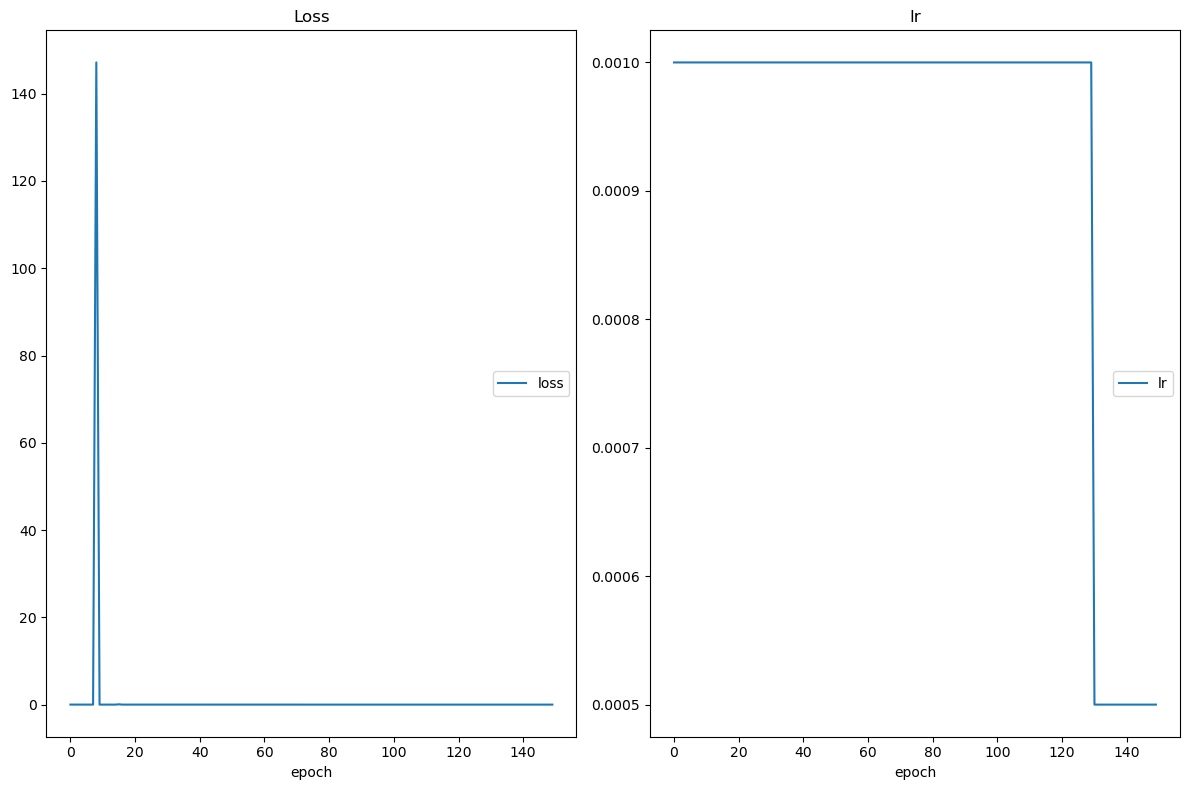

Loss
	loss             	 (min:    0.000, max:  147.168, cur:    0.000)
lr
	lr               	 (min:    0.001, max:    0.001, cur:    0.001)
Treino concluído. Melhor loss: 0.0001
Tempo: 712.6s


In [8]:
def train_vae(model, train_dl, epochs, lr, mse_w, perc_w, kld_w, perc_fn, save_path):
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=15)
    liveloss  = PlotLosses()
    best_loss = float('inf')

    for epoch in range(epochs):
        logs = {}
        model.train()
        running_loss = 0.0

        for imgs in train_dl:
            imgs = imgs.to(device)
            recon, mu, log_var, z = model(imgs)
            loss = vae_perceptual_loss(recon, imgs, mu, log_var, perc_fn, mse_w, perc_w, kld_w)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_dl.dataset)
        logs['loss'] = epoch_loss
        scheduler.step(epoch_loss)
        logs['lr'] = optimizer.param_groups[0]['lr']

        liveloss.update(logs)
        liveloss.send()

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(model, save_path)

    print(f'Treino concluído. Melhor loss: {best_loss:.4f}')
    return model


start = time.perf_counter()
model = train_vae(
    model, train_dl, EPOCHS, LEARNING_RATE,
    MSE_W, PERC_W, KLD_W,
    perceptual_loss_fn, MODEL_PATH
)
print(f'Tempo: {time.perf_counter() - start:.1f}s')

## Verificar Reconstrução
- Carrega o melhor modelo guardado e compara imagens originais vs reconstruídas.
- Se as reconstruções forem de boa qualidade (ductos visíveis, contraste correto),
o VAE aprendeu bem a distribuição da classe e pode gerar imagens plausíveis.

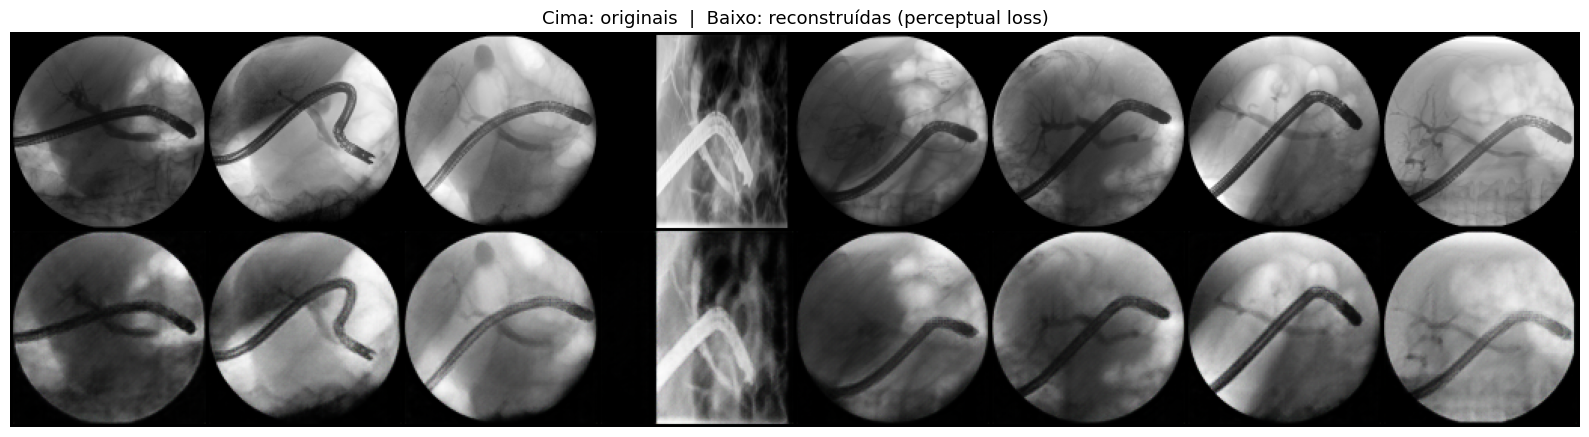

In [9]:
def visualize_reconstruction(model, dataloader, n=8):
    model.eval()
    imgs = next(iter(dataloader))[:n].to(device)
    with torch.no_grad():
        recon, _, _, _ = model(imgs)
    comparison = torch.cat([imgs.cpu(), recon.cpu()])
    grid = make_grid(comparison, nrow=n, normalize=True)
    plt.figure(figsize=(16, 5))
    plt.title('Cima: originais  |  Baixo: reconstruídas (perceptual loss)', fontsize=13)
    plt.axis('off')
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.tight_layout()
    plt.show()

model = torch.load(MODEL_PATH, map_location=device, weights_only=False)
visualize_reconstruction(model, train_dl)

## Geração por Perturbação do Mu
- 1. Encode  de cada imagem real : obtém mu (coordenadas no espaço latente)
- 2. Adiciona pequeno ruído: z = mu + NOISE_SCALE * randn
- 3. Decode z - nova imagem ligeiramente diferente da original

In [10]:
def generate_from_mu(model, dataloader, n_generate, noise_scale, device, output_dir, class_name):
    model.eval()
    save_dir = Path(output_dir) / class_name
    save_dir.mkdir(parents=True, exist_ok=True)

    generated_all = []
    n_done = 0

    with torch.no_grad():
        while n_done < n_generate:
            for imgs in dataloader:
                if n_done >= n_generate:
                    break
                imgs = imgs.to(device)
                mu, log_var = model.encode(imgs)
                z = mu + noise_scale * torch.randn_like(mu)
                generated = model.decode(z).cpu()
                for i, img in enumerate(generated):
                    if n_done >= n_generate:
                        break
                    save_image(img, str(save_dir / f'vae_perc_{n_done:04d}.png'))
                    n_done += 1
                generated_all.append(generated)

    generated_all = torch.cat(generated_all)[:n_generate]
    print(f'{n_done} imagens geradas em: {save_dir}')
    return generated_all


generated = generate_from_mu(
    model, train_dl, N_GENERATE, NOISE_SCALE,
    device, OUTPUT_DIR, TARGET_CLASS
)
print(f'Shape: {generated.shape}')

300 imagens geradas em: vae_generated_perceptual/Normal
Shape: torch.Size([300, 3, 128, 128])


## Visualizar Imagens Geradas

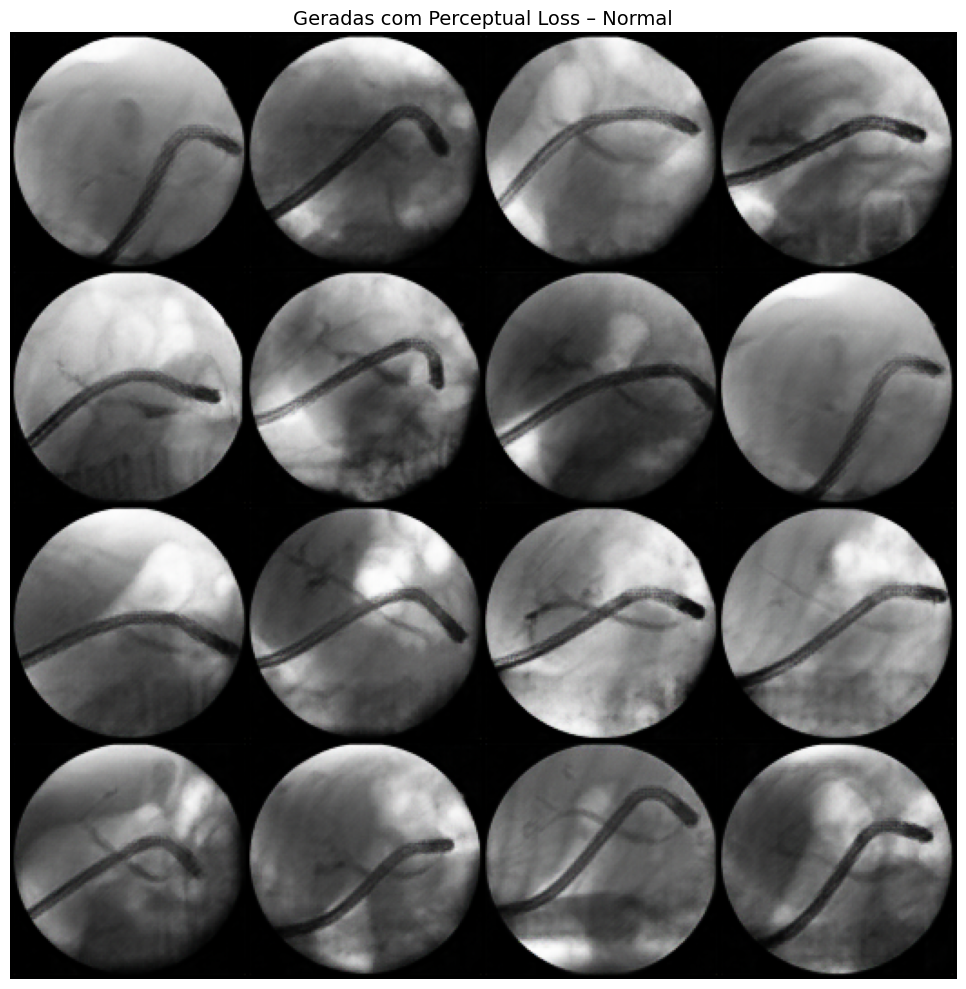

In [11]:
show_images(generated, title=f'Geradas com Perceptual Loss – {TARGET_CLASS}', n=16)

## Interpolação no Espaço Latente
Interpola entre os mu de duas imagens reais para verificar que o espaço
latente é contínuo e coerente: se as imagens intermédias forem plausíveis
e a transição for suave, o VAE aprendeu bem a estrutura da classe.
- NOTA: Esta função é apenas para diagnóstico visual logo não gera imagens
 usadas no augmentation.

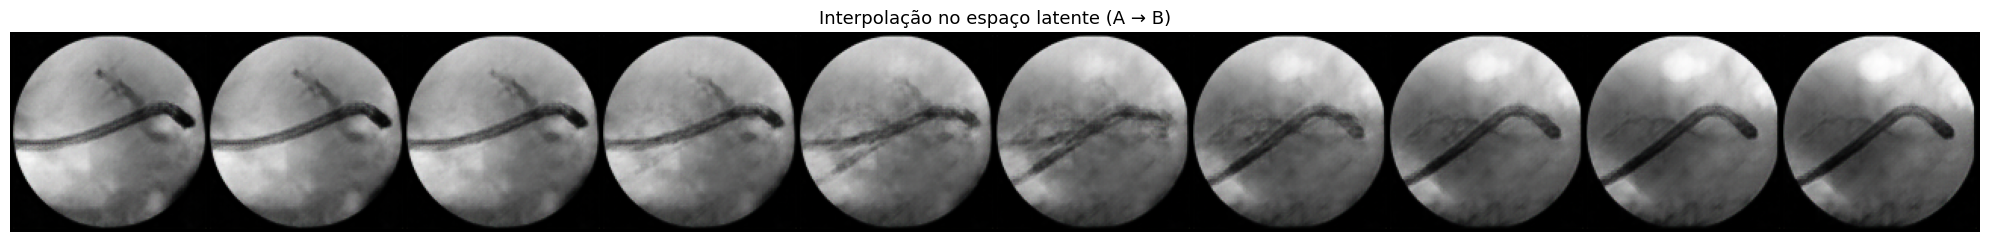

In [12]:
def latent_interpolation(model, dataloader, device, n_steps=10):
    model.eval()
    imgs = next(iter(dataloader))[:2].to(device)
    with torch.no_grad():
        mu1, _ = model.encode(imgs[0:1])
        mu2, _ = model.encode(imgs[1:2])
    interps = []
    for alpha in np.linspace(0, 1, n_steps):
        z = (1 - float(alpha)) * mu1 + float(alpha) * mu2
        with torch.no_grad():
            img = model.decode(z).cpu()
        interps.append(img)
    interps = torch.cat(interps)
    grid = make_grid(interps, nrow=n_steps, normalize=True)
    plt.figure(figsize=(20, 3))
    plt.title('Interpolação no espaço latente (A → B)', fontsize=13)
    plt.axis('off')
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.tight_layout()
    plt.show()

latent_interpolation(model, train_dl, device)

In [13]:
real_count = len(dataset)
gen_count  = len(list(Path(OUTPUT_DIR, TARGET_CLASS).glob('*.png')))
print('=' * 50)
print(f'Classe:           {TARGET_CLASS}')
print(f'Imagens reais:    {real_count}')
print(f'Imagens geradas:  {gen_count}')
print(f'Total disponível: {real_count + gen_count}')
print('=' * 50)
print(f'Modelo: {MODEL_PATH}')
print(f'Imagens: {OUTPUT_DIR}/{TARGET_CLASS}/')

Classe:           Normal
Imagens reais:    197
Imagens geradas:  300
Total disponível: 497
Modelo: ./vae_perceptual_normal.pth
Imagens: ./vae_generated_perceptual/Normal/
